In [2]:
import pandas as pd

data = pd.read_csv('/content/data_ecommerce_customer_churn.csv')
data.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


Di sini terlihat bahwa dataset berisi informasi pelanggan e-commerce, mulai dari durasi berlangganan hingga jumlah *cashback* yang diterima. Dataset ini digunakan untuk memprediksi kemungkinan terjadinya *customer churn*. Selain itu, terdapat beberapa variabel yang memiliki *missing value*, yang dalam proses pengolahan data akan ditangani dengan menggantinya menggunakan nilai median.


# Data Cleaning

In [5]:
data['Tenure'] = data["Tenure"].fillna(data['Tenure'].median())
data["WarehouseToHome"] = data['WarehouseToHome'].fillna(data['WarehouseToHome'].median())
data['DaySinceLastOrder'] = data['DaySinceLastOrder'].fillna(data['DaySinceLastOrder'].median())
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3941 non-null   float64
 1   WarehouseToHome           3941 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3941 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


Setelah itu, dilakukan pemeriksaan untuk memastikan apakah terdapat data duplikat dalam dataset. Apabila ditemukan data duplikat, maka data tersebut akan dihapus. Selain itu, variabel *PreferedOrderCat* dan *MaritalStatus* juga akan dieliminasi dari dataset karena tidak digunakan dalam analisis.
.

In [6]:
print(f"sebelum dihapus: {data.duplicated().sum()}")
data = data.drop_duplicates()
print(f"setelah dihapus: {data.duplicated().sum()}")

sebelum dihapus: 672
setelah dihapus: 0


In [9]:
data = data.drop(['PreferedOrderCat', 'MaritalStatus'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3269 entries, 0 to 3940
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3269 non-null   float64
 1   WarehouseToHome           3269 non-null   float64
 2   NumberOfDeviceRegistered  3269 non-null   int64  
 3   SatisfactionScore         3269 non-null   int64  
 4   NumberOfAddress           3269 non-null   int64  
 5   Complain                  3269 non-null   int64  
 6   DaySinceLastOrder         3269 non-null   float64
 7   CashbackAmount            3269 non-null   float64
 8   Churn                     3269 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 384.4 KB


# Splitting & Standard Scaling Model

In [10]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")

Ukuran X_train: (2615, 8)
Ukuran X_test: (654, 8)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount
0,2.077881,1.945249,0.313230,-1.438468,-0.860198,-0.621126,2.355555,2.369426
1,1.257175,-0.883450,-0.682027,-0.717580,-0.474297,-0.621126,0.698662,-0.759307
2,-0.853211,-0.883450,0.313230,-0.717580,0.683407,1.609979,-1.234380,-0.190154
3,0.201982,-0.412000,-0.682027,0.724196,0.297506,-0.621126,-0.682082,0.111743
4,0.084738,-0.765588,-0.682027,0.003308,-0.088396,1.609979,-0.682082,-0.705735


# Modelling KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Inisialisasi dan melatih model KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [25]:
# Melakukan prediksi
y_pred = knn.predict(X_test_scaled)

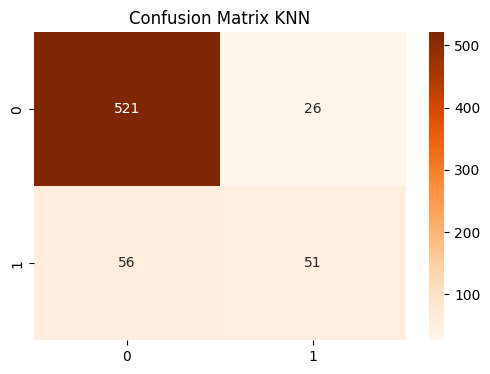

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix KNN')
plt.show()

In [27]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8746

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       547
           1       0.66      0.48      0.55       107

    accuracy                           0.87       654
   macro avg       0.78      0.71      0.74       654
weighted avg       0.86      0.87      0.87       654



Hasil *modelling* menunjukkan adanya bias pada karena cenderung ke kelas 0, bisa dilihat melalui f1-score kelas 1 hanya 0,55. Ada kemungkinan data kebanyakan di kelas 0.

In [17]:
data['Churn'].value_counts()

,count
Churn,
0,2735
1,534


Terlihat bahwa terdapat ketidakseimbangan (*imbalance*) yang cukup signifikan antara kelas 0 dan kelas 1. Oleh karena itu, akan dilakukan penanganan terhadap kondisi tersebut menggunakan teknik *oversampling* untuk menyeimbangkan distribusi kelas.


### Melatih Ulang Model KNN dengan Data yang Sudah Seimbang

In [42]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Inisialisasi RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train_scaled, y_train)

# Melatih kembali model KNN dengan data Over-sampled
knn_over = KNeighborsClassifier(n_neighbors=5)
knn_over.fit(X_train_over, y_train_over)

y_pred_over = knn_over.predict(X_test_scaled)

print(f"Jumlah data sebelum Over-sampling: {Counter(y_train)}")
print(f"Jumlah data setelah Over-sampling: {Counter(y_train_over)}")

Jumlah data setelah Over-sampling: Counter({0: 2188, 1: 427})
Jumlah data setelah Over-sampling: Counter({0: 2188, 1: 2188})


Random Over Sampling (ROS) menduplikasi sampel dari kelas minoritas secara acak. Dari situ terlihat perbandingan data yang jelas dari sekitar 5:1 menjadi 5:5.

In [39]:
print(f"\nAccuracy Score (Over-sampling): {accuracy_score(y_test, y_pred_over):.4f}")
print("\nClassification Report (Over-sampling):")
print(classification_report(y_test, y_pred_over))


Accuracy Score (Over-sampling): 0.7844

Classification Report (Over-sampling):
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       547
           1       0.42      0.79      0.54       107

    accuracy                           0.78       654
   macro avg       0.68      0.78      0.70       654
weighted avg       0.86      0.78      0.81       654



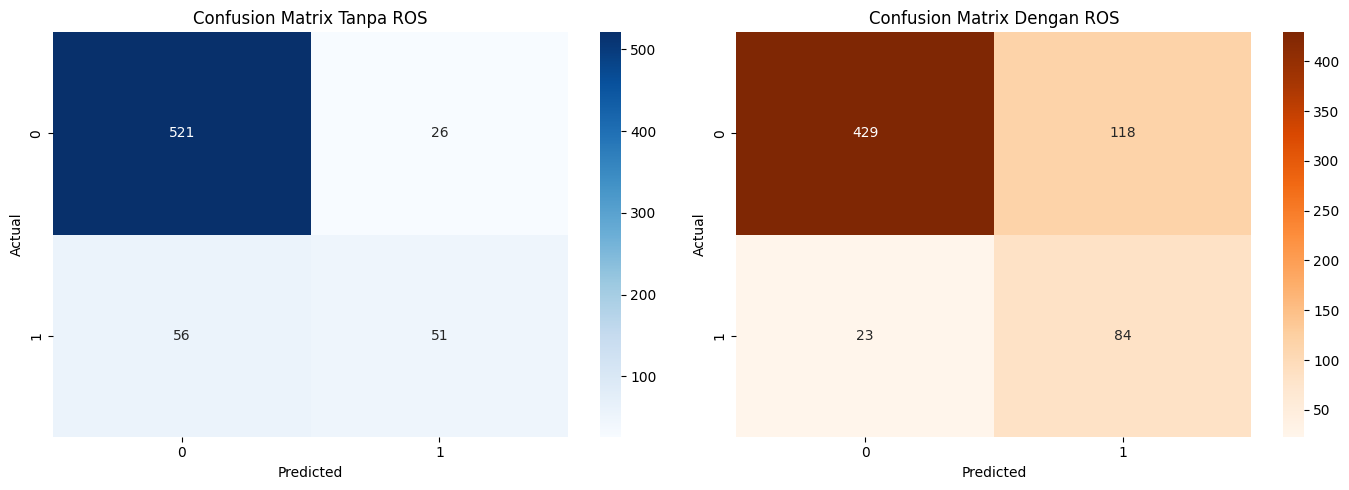

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Tanpa ROS
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix Tanpa ROS')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Confusion Matrix Dengan ROS
sns.heatmap(confusion_matrix(y_test, y_pred_over), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Confusion Matrix Dengan ROS')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [38]:
print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred_over))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       547
           1       0.66      0.48      0.55       107

    accuracy                           0.87       654
   macro avg       0.78      0.71      0.74       654
weighted avg       0.86      0.87      0.87       654

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       547
           1       0.42      0.79      0.54       107

    accuracy                           0.78       654
   macro avg       0.68      0.78      0.70       654
weighted avg       0.86      0.78      0.81       654



Meskipun model KNN tanpa penerapan metode ROS menunjukkan tingkat akurasi yang lebih tinggi, model tersebut cenderung hanya mampu mengenali kelas 0. Hal ini terlihat dari banyaknya kesalahan dalam memprediksi kelas 1. Setelah diterapkan metode ROS, kemampuan model dalam mengklasifikasikan kelas 1 mengalami peningkatan. Namun, peningkatan ini diikuti dengan penurunan performa dalam memprediksi kelas 0 dibandingkan dengan model tanpa ROS.
